In [1]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import (
    EarlyStopping, 
    ModelCheckpoint, 
    LearningRateMonitor,
    RichProgressBar
)

from data import SyntheticLogReturnsDataset, generate_datasets
from model import FinancialLSTMModule

/home/marko/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Config

In [2]:
config = {
    'N_DATASET_TRAIN': 70,
    'N_DATASET_VAL'  : 20,
    'N_DATASET_TEST' : 10,
    'N_STOCK'        : 8,
    'N_WINDOWS'      : 500,
    'DISTRIBUTION'   :'normal',
    'SEED'           : np.random.randint(0, 1e6),

    'LOOKBACK_WINDOW': 60,
    'TARGET_WINDOW'  : 20,
    'HIDDEN_SIZE'    : 64,
    'NUM_LAYERS'     : 2,
    'DROPOUT'        : 0.2,
    'TASK'           : 'prediction',
    'LEARNING_RATE'  : 1e-4,

    'NUM_EPOCHS'     : 16,
    'BATCH_SIZE'     : 16,
    'SHUFFLE_BATCHES': True,
    
    'PATIENCE' : -1,
    'MIN_DELTA': 1e-6,
    'OVERLAPPING_WINDOWS': False
}

PATH = [
    'logs/financial_lstm', # Save dir
    'v6',                  # Name
    'prediction_run=Large_batch=16_warmup' # Version
]

## Datasets and DataLoaders

In [3]:
train_datasets, val_datasets, test_datasets = generate_datasets(config)

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=config['BATCH_SIZE'], shuffle=config['SHUFFLE_BATCHES'])
val_loader   = DataLoader(ConcatDataset(val_datasets), batch_size=config['BATCH_SIZE'], shuffle=False)
test_loader  = DataLoader(ConcatDataset(test_datasets),  batch_size=1, shuffle=False)

## Model

In [4]:
#model = FinancialLSTMModule(config)
model = FinancialLSTMModule.load_from_checkpoint('logs/financial_lstm/v6/prediction_run=Large_batch=16_warmup/checkpoints/last.ckpt', config)

# Compile the model
model = torch.compile(model)

## Trainer

#### Logger

In [5]:
tb_logger = TensorBoardLogger(
    save_dir          = PATH[0],
    name              = PATH[1],
    version           = PATH[2],
    default_hp_metric = True
)

#### Callbacks

In [ ]:
callbacks = [
    ModelCheckpoint(
        dirpath=f"{PATH[0]}/{PATH[1]}/{PATH[2]}/checkpoints",
        filename="best_{epoch:02d}_{val_loss:.6f}",
        monitor="val_loss",
        mode="min",
        save_last=True,
        auto_insert_metric_name=True
    ),
    
    LearningRateMonitor(
        logging_interval="epoch",
        log_momentum=False
    ),
    
    RichProgressBar()
]

if config['PATIENCE'] > 0:
    early_stopping = EarlyStopping(
        monitor   = 'val_loss',
        min_delta = config['MIN_DELTA'],
        patience  = config['PATIENCE'],
        mode      = 'min'
    )

    callbacks.append(early_stopping)

#### Trainer

In [ ]:
trainer = pl.Trainer(
    max_epochs = config['NUM_EPOCHS'],
    logger     = tb_logger,
    callbacks  = callbacks,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=10,
    enable_progress_bar=True,
    enable_model_summary=True,   
    gradient_clip_val=1.0
)

## Train model

In [ ]:
# ==================== Train the Model ====================
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

trainer.fit(model, train_loader, val_loader)

# ==================== Print Results ====================
print("\n" + "="*50)
print("Training Complete!")
print("="*50)
print(f"Best model path: {trainer.checkpoint_callback.best_model_path}")
print(f"Best validation loss: {trainer.checkpoint_callback.best_model_score:.6f}")
print("="*50 + "\n")

## Resume training

## Load model

# Benchmark

In [6]:
from scipy import stats

def OLS_on_sample(stock_returns, r_market, r_market_target):
    beta, alpha, _, _, _ = stats.linregress(r_market, stock_returns)
    reconstruction = alpha + beta * r_market_target
    return reconstruction, alpha, beta

In [7]:
true_alphas = torch.stack([test_dataset.alphas for test_dataset in test_datasets])
true_betas  = torch.stack([test_dataset.betas for test_dataset in test_datasets])

loss_function = torch.nn.MSELoss(reduction='mean')

model_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

ols_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

n_stock = config['N_STOCK']
len_dataset = n_stock * config['N_WINDOWS']

start_time = time.time()
print("Evauating model on test set...")

model.eval()
with torch.no_grad():
    for i, data in enumerate(test_loader):
        curr_dataset = i // len_dataset
        curr_stock = i % n_stock

        true_alpha = true_alphas[curr_dataset, curr_stock]
        true_beta  = true_betas[curr_dataset, curr_stock]

        stock_returns = data['stock_returns_context']
        r_market      = data['r_market_context']
        target        = data['target']

        if config['TASK'] == 'prediction':
            r_market_next = data['r_market_target']
        else:
            r_market_next = r_market
        
        # Model loss
        reconstruction, alpha, beta = model(stock_returns, r_market, r_market_next)
        model_summary['recon_loss'].append(loss_function(reconstruction, target).item())
        model_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        model_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        model_summary['alpha'].append(alpha.detach())
        model_summary['beta'].append(beta.detach())

        
        #OLS and OLS loss
        stock_returns = stock_returns.squeeze()
        r_market      = r_market.squeeze()
        target        = target.squeeze()

        if config['TASK'] == 'prediction':
            r_market_next = r_market_next.squeeze()
        
        reconstruction, alpha, beta = OLS_on_sample(stock_returns, r_market, r_market_next)
        alpha, beta = torch.Tensor([alpha]), torch.Tensor([beta])
        ols_summary['recon_loss'].append(loss_function(reconstruction, target).item())
        ols_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        ols_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        ols_summary['alpha'].append(alpha)
        ols_summary['beta'].append(beta)

model_summary['alpha'] = torch.Tensor(model_summary['alpha']).reshape(config['N_DATASET_TEST'], config['N_WINDOWS'], config['N_STOCK'])
model_summary['beta'] = torch.Tensor(model_summary['beta']).reshape(config['N_DATASET_TEST'], config['N_WINDOWS'], config['N_STOCK'])

ols_summary['alpha'] = torch.Tensor(ols_summary['alpha']).reshape(config['N_DATASET_TEST'], config['N_WINDOWS'], config['N_STOCK'])
ols_summary['beta'] = torch.Tensor(ols_summary['beta']).reshape(config['N_DATASET_TEST'], config['N_WINDOWS'], config['N_STOCK'])

print(f"Done! time = {time.time() - start_time:>7f} seconds")

Evauating model on test set...


/home/marko/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/marko/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Done! time = 70.612581 seconds


In [8]:
# Calculate test metrics for hp_metric
model_test_loss = np.mean(model_summary['recon_loss'])
ols_test_loss = np.mean(ols_summary['recon_loss'])

# Log hp_metric (model_test_loss)
tb_logger.log_hyperparams(
    params=config,
    metrics={'hp_metric': model_test_loss}
)

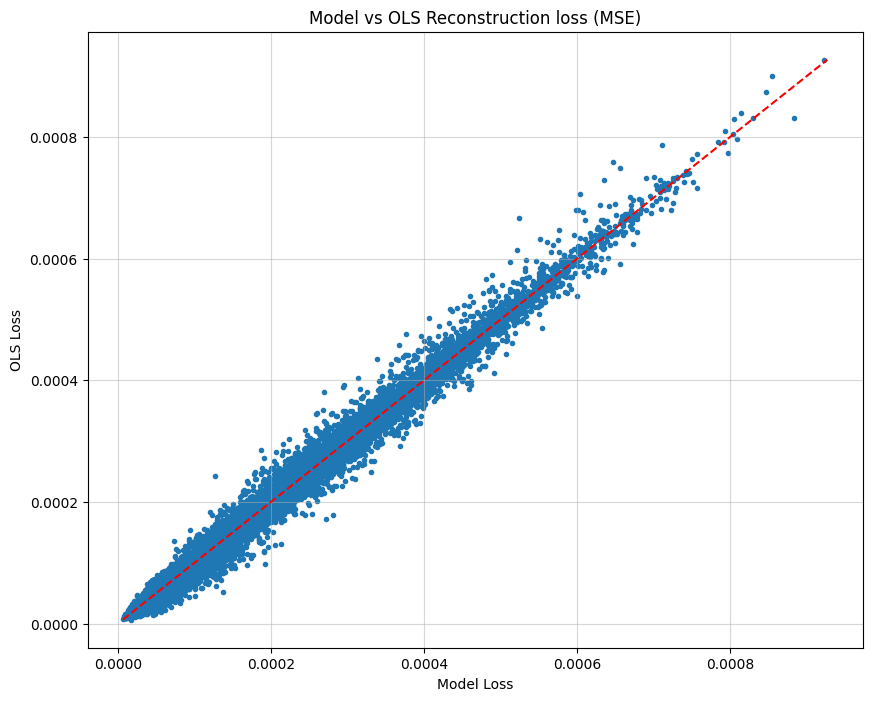

In [10]:
plt.figure(figsize=(10, 8))

plt.scatter(model_summary['recon_loss'], ols_summary['recon_loss'], marker='.')
plt.xlabel('Model Loss')
plt.ylabel('OLS Loss')

identity = np.linspace(min(ols_summary['recon_loss']), max(ols_summary['recon_loss']), 1000)
plt.plot(identity, identity, 'r--')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE)', plt.gcf())
plt.show()

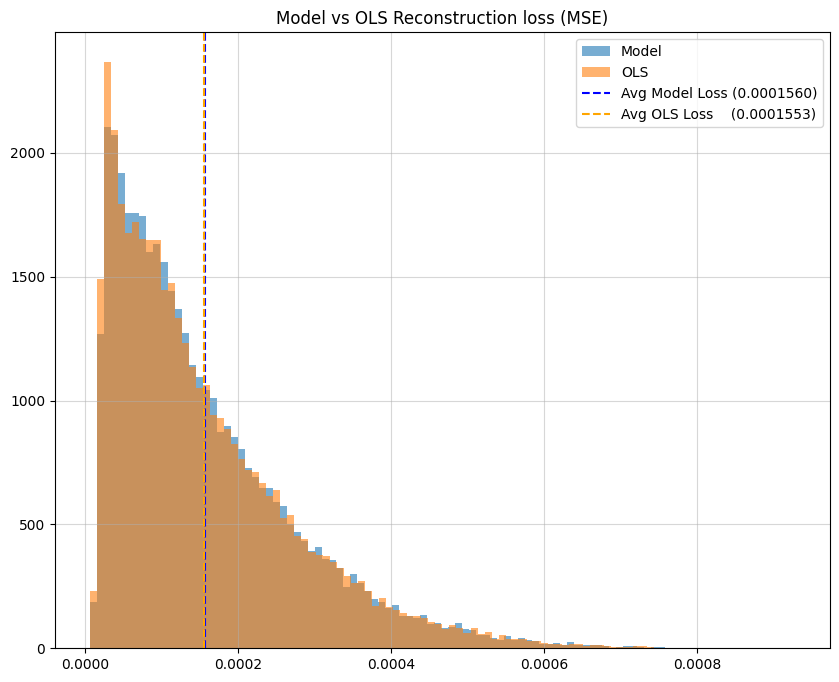

In [11]:
plt.figure(figsize=(10, 8))

plt.hist(model_summary['recon_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['recon_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_test_loss:.7f})')
plt.axvline(ols_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_test_loss:.7f})')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE) Histogram', plt.gcf())
plt.show()

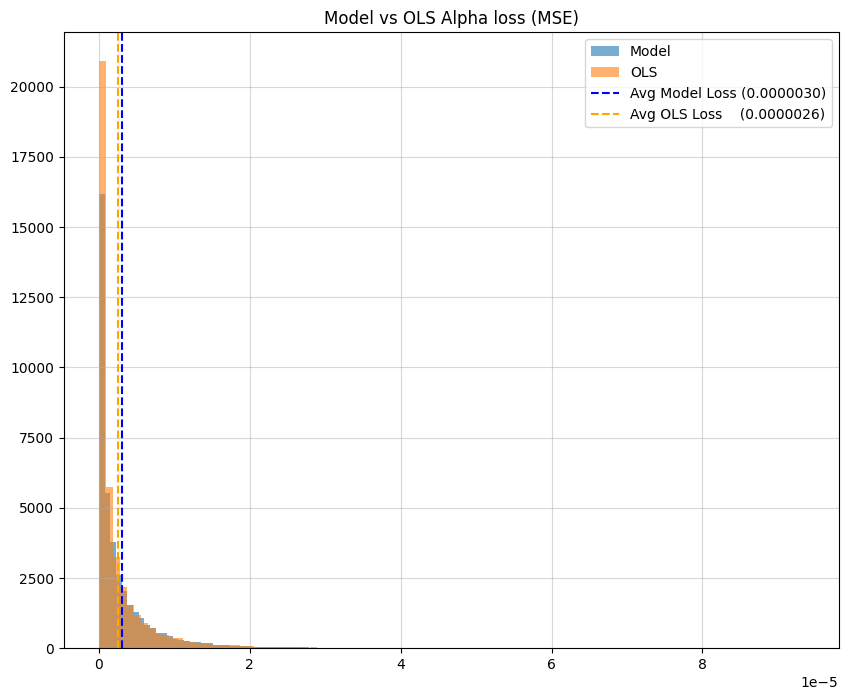

In [12]:
model_alpha_test_loss = np.mean(model_summary['alpha_loss'])
ols_alpha_test_loss = np.mean(ols_summary['alpha_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['alpha_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['alpha_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_alpha_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_alpha_test_loss:.7f})')
plt.axvline(ols_alpha_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_alpha_test_loss:.7f})')

plt.title('Model vs OLS Alpha loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Alpha loss (MSE)', plt.gcf())
plt.show()

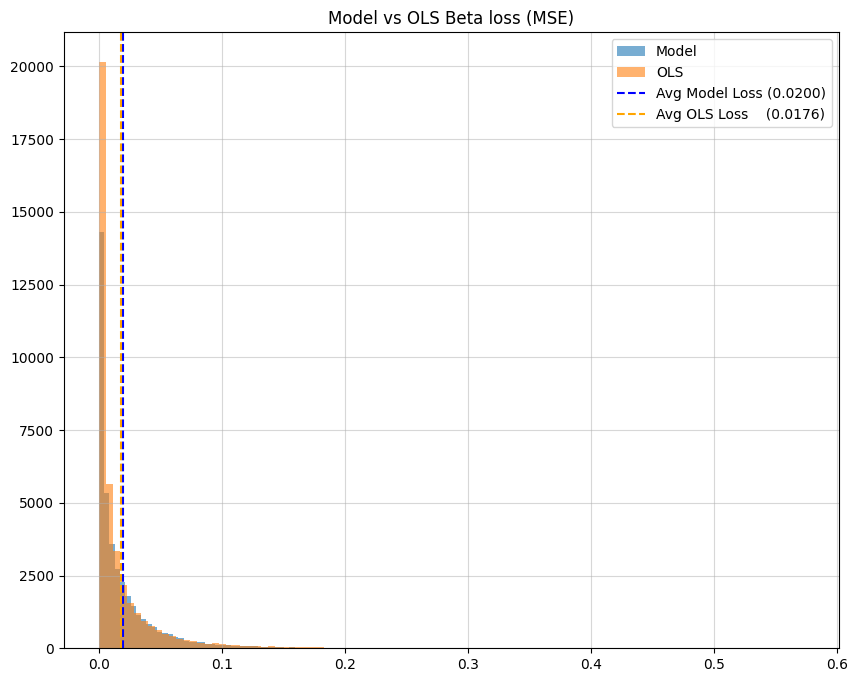

In [13]:
model_beta_test_loss = np.mean(model_summary['beta_loss'])
ols_beta_test_loss = np.mean(ols_summary['beta_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['beta_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['beta_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_beta_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_beta_test_loss:.4f})')
plt.axvline(ols_beta_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_beta_test_loss:.4f})')

plt.title('Model vs OLS Beta loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Beta loss (MSE)', plt.gcf())
plt.show()

In [14]:
tb_logger.experiment.add_scalar('test/model_alpha_loss', model_alpha_test_loss)
tb_logger.experiment.add_scalar('test/model_beta_loss', model_beta_test_loss)
idxs = list(range(9))

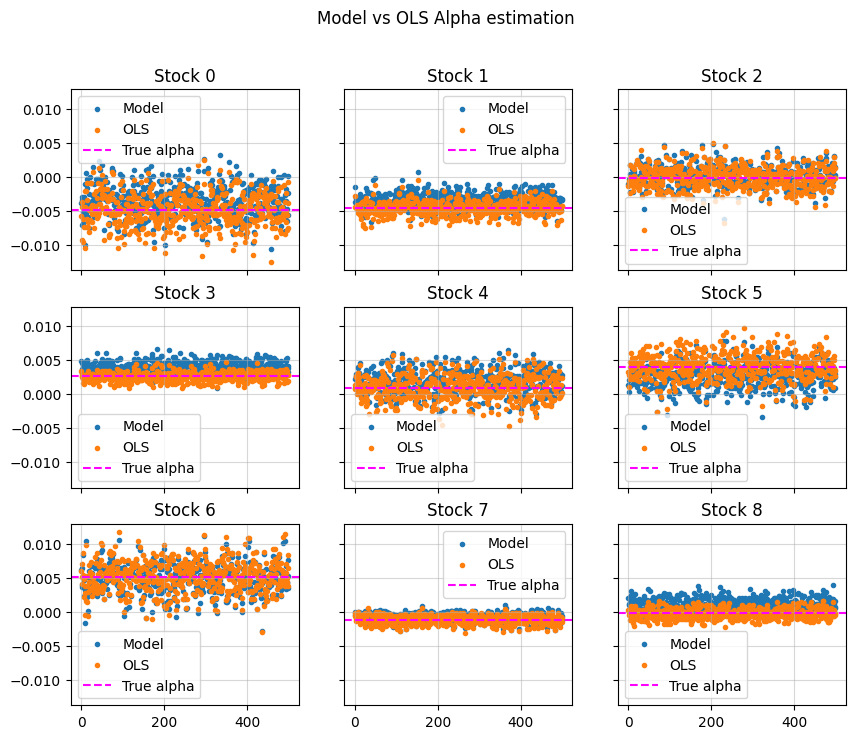

In [15]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Alpha estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_STOCK']
    
    true_alpha  = true_alphas[dataset_idx, stock_idx]
    model_alpha = model_summary['alpha'][dataset_idx, :, stock_idx]
    ols_alpha   = ols_summary['alpha'][dataset_idx, :, stock_idx]

    sample = np.arange(len(model_alpha))

    ax.set_title(f'Stock {idx}')
    ax.scatter(sample, model_alpha, label='Model', marker='.')
    ax.scatter(sample, ols_alpha, label='OLS', marker='.')
    ax.axhline(true_alpha, color='magenta', linestyle='--', label='True alpha')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Alpha estimation', fig)
plt.show()

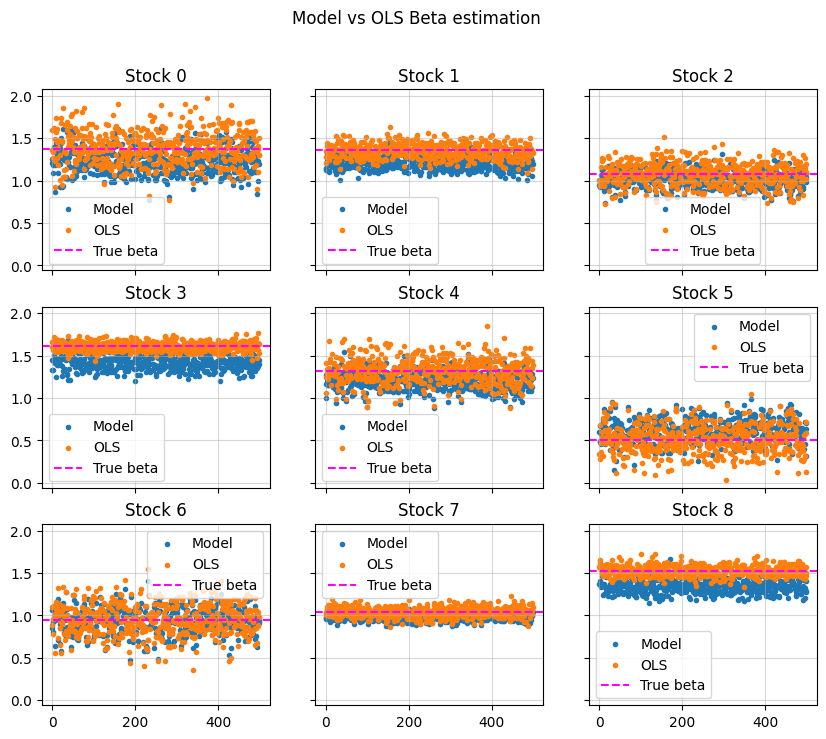

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Beta estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_STOCK']
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta   = ols_summary['beta'][dataset_idx, :, stock_idx]

    sample = np.arange(len(model_beta))

    ax.set_title(f'Stock {idx}')
    ax.scatter(sample, model_beta, label='Model', marker='.')
    ax.scatter(sample, ols_beta, label='OLS', marker='.')
    ax.axhline(true_beta, color='magenta', linestyle='--', label='True beta')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
#tb_logger.experiment.add_figure('Model vs OLS Beta estimation', fig)
plt.show()

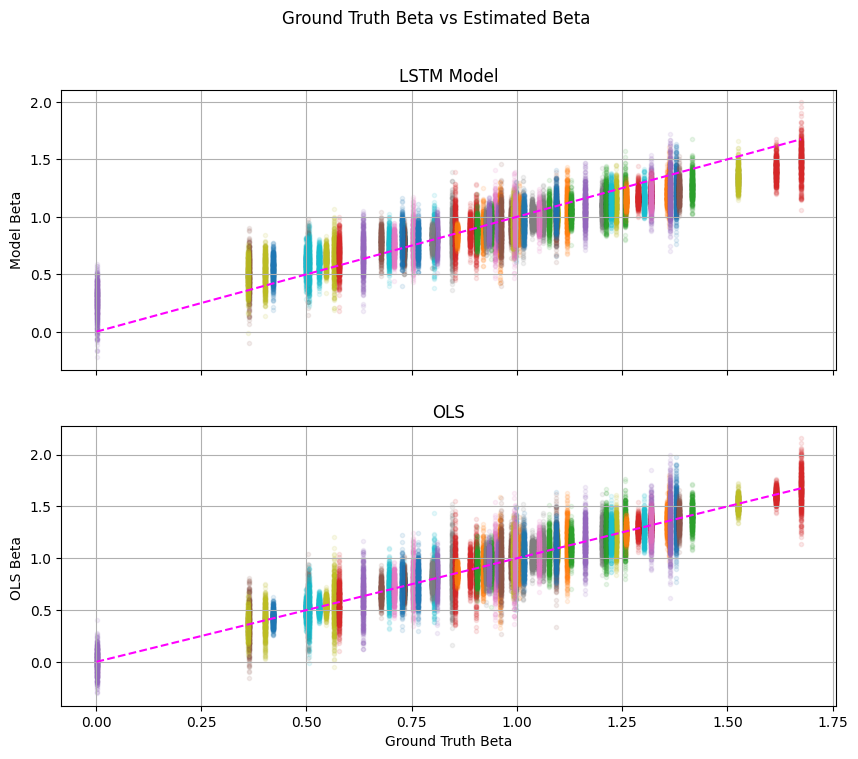

In [17]:
idxs = list(range(config['N_STOCK'] * config['N_DATASET_TEST']))
n = config['N_WINDOWS']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Ground Truth Beta vs Estimated Beta')

identity = np.linspace(true_betas.min(), true_betas.max(), 1000)

# Top subplot - Model
ax1.set_title('LSTM Model')
ax1.set_ylabel('Model Beta')
ax1.plot(identity, identity, color='magenta', linestyle='--')
ax1.grid()

# Bottom subplot - OLS
ax2.set_title('OLS')
ax2.set_xlabel('Ground Truth Beta')
ax2.set_ylabel('OLS Beta ')
ax2.plot(identity, identity, color='magenta', linestyle='--')
ax2.grid()

for idx in idxs:
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_STOCK']
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta   = ols_summary['beta'][dataset_idx, :, stock_idx]

    x = [true_beta] * n

    ax1.scatter(x, model_beta, marker='.', alpha=0.1)
    ax2.scatter(x, ols_beta, marker='.', alpha=0.1)

#tb_logger.experiment.add_figure('Ground Truth Beta vs Estimated Beta', fig)
plt.show()

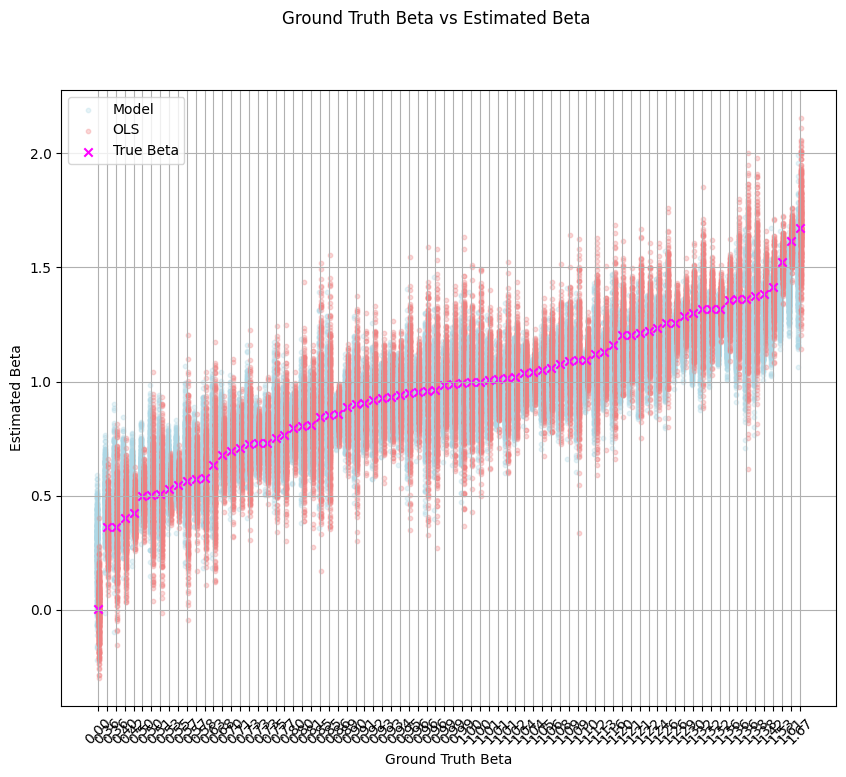

In [18]:
idxs = list(range(config['N_STOCK'] * config['N_DATASET_TEST']))
n = config['N_WINDOWS']

# Collect all errors organized by true beta value
from collections import defaultdict
model_betas = defaultdict(list)
ols_betas = defaultdict(list)

for idx in idxs:
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_STOCK']
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta  = ols_summary['beta'][dataset_idx, :, stock_idx]

    model_betas[true_beta].extend(model_beta)
    ols_betas[true_beta].extend(ols_beta)

# Sort by true beta values
sorted_betas = sorted(model_betas.keys())

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Ground Truth Beta vs Estimated Beta')

# Create positions for scatterplots
positions_model = np.arange(len(sorted_betas)) * 3
positions_ols = positions_model + 1

# Plot scatterplots
for i, beta in enumerate(sorted_betas):
    x_model = [positions_model[i]] * len(model_betas[beta])
    x_ols = [positions_ols[i]] * len(ols_betas[beta])
    
    ax.scatter(x_model, model_betas[beta], color='lightblue', alpha=0.3, s=10, label='Model' if i == 0 else '')
    ax.scatter(x_ols, ols_betas[beta], color='lightcoral', alpha=0.3, s=10, label='OLS' if i == 0 else '')

ax.set_xlabel('Ground Truth Beta')
ax.set_ylabel('Estimated Beta')
ax.set_xticks(positions_model + 0.5)
ax.set_xticklabels([f'{beta:.2f}' for beta in sorted_betas], rotation=45)
ax.scatter(positions_model + 0.5, sorted_betas, color='magenta', marker='x', label='True Beta')
ax.legend()
ax.grid()

#tb_logger.experiment.add_figure('Ground Truth Beta vs Estimated Beta (Alternative)', fig)
plt.show()

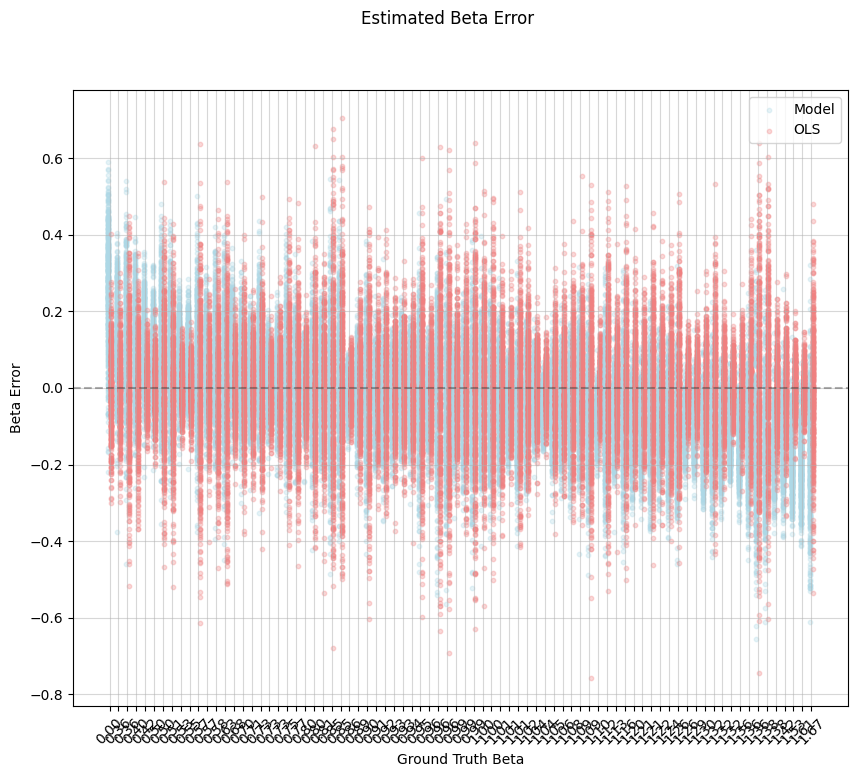

In [19]:
idxs = list(range(config['N_STOCK'] * config['N_DATASET_TEST']))
n = config['N_WINDOWS']

# Collect all errors organized by true beta value
from collections import defaultdict
model_errors = defaultdict(list)
ols_errors = defaultdict(list)

for idx in idxs:
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_STOCK']
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta_err = model_summary['beta'][dataset_idx, :, stock_idx] - true_beta
    ols_beta_err   = ols_summary['beta'][dataset_idx, :, stock_idx] - true_beta

    model_errors[true_beta].extend(model_beta_err)
    ols_errors[true_beta].extend(ols_beta_err)

# Sort by true beta values
sorted_betas = sorted(model_errors.keys())

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Estimated Beta Error')

# Create positions for scatterplots
positions_model = np.arange(len(sorted_betas)) * 3
positions_ols = positions_model + 1

# Plot scatterplots
for i, beta in enumerate(sorted_betas):
    x_model = [positions_model[i]] * len(model_errors[beta])
    x_ols = [positions_ols[i]] * len(ols_errors[beta])
    
    ax.scatter(x_model, model_errors[beta], color='lightblue', alpha=0.3, s=10, label='Model' if i == 0 else '')
    ax.scatter(x_ols, ols_errors[beta], color='lightcoral', alpha=0.3, s=10, label='OLS' if i == 0 else '')

ax.set_xlabel('Ground Truth Beta')
ax.set_ylabel('Beta Error')
ax.set_xticks(positions_model + 0.5)
ax.set_xticklabels([f'{beta:.2f}' for beta in sorted_betas], rotation=45)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.legend()
ax.grid(alpha=0.5)

#tb_logger.experiment.add_figure('Estimated Beta Error', fig)
plt.show()

In [ ]:
tb_logger.save()